**IMPORTS & SETUP**

In [1]:
import pandas as pd
import numpy as np
import requests
import joblib
import matplotlib.pyplot as plt
from collections import Counter

# sklearn imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report


**LOAD & CLEAN DATA**

In [2]:
df  = pd.read_csv("csv/combined.csv")
df.drop_duplicates(inplace=True) # Remove duplicate rows
df["years_of_experience"] = pd.to_numeric(df["years_of_experience"], errors="coerce").fillna(0) # Clean numeric columns

In [3]:
text_columns = [
    "education_degree", "education_institution", 
    "total_skills", "certifications", 
    "city", "state"
]

for col in text_columns:
    df[col] = df[col].fillna("Unknown").astype(str)

In [4]:
# Clean up
df.fillna("Unknown", inplace=True)

In [5]:
mapping = {
    'ml_engineer':'ML_Eng', 'ml_engineers':'ML_Eng',
    'data_scientists':'DS', 'data_analysts':'DA',
    'business_analyst_Final':'BA', 
    'businees_intelligence_developerss':'BI_Dev',
    'backendFinal':'Backend_Dev', 'frontendFinal':'Frontend_Dev',
    'fullstackFinal':'Fullstack_Dev', 'mobiledevFinal':'Mobile_Dev',
    'blockchain_developers':'Blockchain_Dev', 'web3_developers':'Web3_Dev',
    'security_analyst':'Security_Analyst', 'mlopss':'MLOps_Eng'
}

df['profile_type'] = df['profile_type'].replace(mapping)


**FEATURE PREPROCESSING + TRAIN A CLASSIFIER**

In [6]:
y = df["profile_type"]
X = df[[
    "years_of_experience", "education_degree", "education_institution",
    "total_skills", "certifications", "city", "state"
]]

In [7]:
print(type(X))  # Should output: <class 'pandas.core.frame.DataFrame'>
print(X.columns)


<class 'pandas.core.frame.DataFrame'>
Index(['years_of_experience', 'education_degree', 'education_institution',
       'total_skills', 'certifications', 'city', 'state'],
      dtype='object')


In [8]:
# Target and features
y = df["profile_type"]
X = df[[
    "years_of_experience",
    "education_degree",
    "education_institution",
    "total_skills",
    "certifications",
    "city",
    "state",
]]

# Encode target labels (string -> integers)
le = LabelEncoder()
y_encoded = le.fit_transform(y)


# Feature groups
numeric_features = ["years_of_experience"]
categorical_features = ["education_degree", "education_institution", "city", "state"]

# Text pipelines
text_transformer_skills = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words='english', max_features=500))
])
text_transformer_certs = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words='english', max_features=200))
])

# Column transformer for preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("skills", text_transformer_skills, "total_skills"),
    ("certs", text_transformer_certs, "certifications"),
])

# Full pipeline with XGBoost
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_estimators=500,
        max_depth=6,
        learning_rate=0.1
    ))
])

#  Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Fit the model
model.fit(X_train, y_train)

#  Predict & evaluate
y_pred_encoded = model.predict(X_test)

# Convert predictions back to original labels
y_pred = le.inverse_transform(y_pred_encoded)
y_test_labels = le.inverse_transform(y_test)

# Print classification report
print(classification_report(y_test_labels, y_pred, zero_division=0))


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [07:21:25] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                  precision    recall  f1-score   support

              BA       0.73      0.68      0.71        60
          BI_Dev       0.83      0.84      0.84       100
     Backend_Dev       0.74      0.73      0.73       100
  Blockchain_Dev       0.40      0.40      0.40        10
              DA       0.00      0.00      0.00        10
              DS       0.00      0.00      0.00        10
    Frontend_Dev       0.24      0.27      0.26       100
   Fullstack_Dev       0.10      0.10      0.10       100
       MLOps_Eng       0.85      0.68      0.75        59
          ML_Eng       0.79      0.97      0.87       187
      Mobile_Dev       0.92      0.89      0.91        76
Security_Analyst       0.91      0.91      0.91        90
        Web3_Dev       0.00      0.00      0.00        10
  data_engineers       0.25      0.10      0.14        10

        accuracy                           0.66       922
       macro avg       0.48      0.47      0.47       922
    weighted

In [9]:
# Save the trained pipeline
joblib.dump(model, "models/profile_type_xgb_pipeline.joblib")
joblib.dump(le, "encoders/label_encoder.joblib")

['encoders/label_encoder.joblib']

In [10]:
# Load the trained pipeline
model = joblib.load("models/profile_type_xgb_pipeline.joblib")


In [11]:
new_profiles = pd.DataFrame([{
    "years_of_experience": 5,
    "education_degree": "B.Tech",
    "education_institution": "IIT Delhi",
    "total_skills": "Python, Machine Learning, Data Analysis",
    "certifications": "AWS Certified Machine Learning",
    "city": "Bangalore",
    "state": "Karnataka",
},
{
    "years_of_experience": 3,
    "education_degree": "M.Sc",
    "education_institution": "IISc Bangalore",
    "total_skills": "React, JavaScript, Frontend Development",
    "certifications": "",
    "city": "Bangalore",
    "state": "Karnataka",
}])


In [12]:
# Predict numeric labels
y_pred_encoded = model.predict(new_profiles)
# Convert numeric labels back to original string labels
# Make sure to use the same LabelEncoder used during training
y_pred = le.inverse_transform(y_pred_encoded)

print(y_pred)


['ML_Eng' 'Fullstack_Dev']


In [13]:
df.head()

,current_position,current_company,years_of_experience,total_skills,education_degree,education_institution,certifications,city,state,country,profile_type
0,ML Engineer,Adobe,11.0,"Matlab, Electronics, C, C++, Electrical Engine...",Bachelor of Engineering (BE),Anna University,Unknown,Bengaluru,Karnataka,India,ML_Eng
1,Machine Learning Engineer,Sarvam,7.0,"Artificial Intelligence (AI), Machine Learning...",BSc - Bachelor of Science,"St. Stephen's College, Delhi",4-Week Virtual Internship Program on Generativ...,Bengaluru,Karnataka,India,ML_Eng
2,Python Software Developer,Wipzent,3.1,"Artificial Intelligence (AI), Django, Pandas (...",Bsc in data science,Techno India University,Unknown,Bengaluru,Karnataka,India,ML_Eng
3,Machine Learning Engineer,Smart Data Solutions,9.2,"Semantic Search, Model Selection, Decision-Mak...",Predictive Analytics for Business,Udacity,"SQL (Basic) Certificate, Databases for Develop...",Chennai,Tamil Nadu,India,ML_Eng
4,Director - Applied AI,Krutrim,15.6,"Coaching, Responsible AI, Analytical Skills, T...",Doctor of Philosophy (Ph.D.),Tampere University,"Neural Networks for Machine Learning, Machine ...",Bengaluru,Karnataka,India,ML_Eng


In [15]:
numeric_features = ["years_of_experience"]
categorical_features = ["education_degree", "education_institution", "city", "state"]

In [17]:
df.tail()

,current_position,current_company,years_of_experience,total_skills,education_degree,education_institution,certifications,city,state,country,profile_type,num_skills,skill_cluster,skills_emb
4601,Data Scientist,Aroha Technologies,13.8,"SQL / RDBMS, Prompt Engineering, Mentoring, Na...",Bachelor of Engineering - BE,Visvesvaraya Technological University,"Clinical Trial Data Analysis using SAS , Clini...",Bengaluru,Karnataka,India,DS,28,4,"[-0.049159452, -0.0012689693, -0.026346311, -0..."
4602,Senior Data Scientist,PayPal,10.0,"Time Series Forecasting, Pattern Recognition, ...",Post Graduation Program,Great Learning,Unknown,Bengaluru,Karnataka,India,DS,22,6,"[-0.08424982, 0.0064264373, -0.01670583, 0.012..."
4603,Junior Data Scientist,LTIMindtree,1.8,"PyTorch, PySpark, GCP, Google Maps API, Google...",Bachelor of Technology - BTech,Graphic Era Deemed to be University,"AWS Certified AI Practitioner, Prompt Engineer...",Bengaluru,Karnataka,India,DS,41,2,"[-0.04801102, -0.010546091, 0.012948728, 0.004..."
4604,Data Scientist,Citi,8.2,Unknown,Master of Technology - MTech,"Indian Statistical Institute, Kolkata",Unknown,Bengaluru,Karnataka,India,DS,0,2,"[-0.04097437, 0.058357716, -0.046086606, -0.00..."
4605,Data Scientist,Genpact,2.2,"R (Programming Language), Object-Oriented Prog...",Master of Computer Applications - MCA,National Institute of Technology Warangal,"Problem Solving(Intermediate) , Problem solvin...",Bengaluru,Karnataka,India,DS,22,4,"[-0.042479843, -0.002658718, 0.008255015, 0.01..."


In [20]:
type(df["skills_emb"].iloc[0])


str

In [21]:
import ast
df["skills_emb"] = df["skills_emb"].apply(
    lambda x: np.array(ast.literal_eval(x), dtype=np.float32)
)

**EMBEDDINGS FOR SKILL CLUSTERING**

In [30]:
OLLAMA_URL = "http://localhost:11434/api/embed"
MODEL_NAME = "bge-m3"

def embed_texts(texts):
    """Embed text list using local Ollama API."""
    r = requests.post(OLLAMA_URL, json={"model": MODEL_NAME, "input": texts})
    r.raise_for_status()
    return np.array(r.json()["embeddings"])

print("\n🧬 Generating embeddings for skills...")
# df["skills_emb"] = embed_texts(df["total_skills"].tolist()).tolist()


🧬 Generating embeddings for skills...


**FIND OPTIMAL NUMBER OF CLUSTERS (K)**

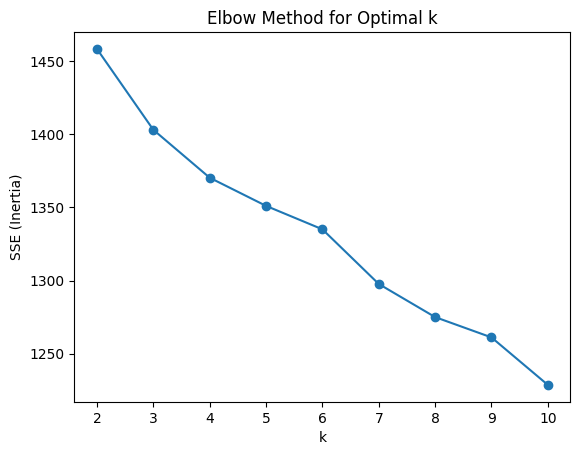

k=2, silhouette=0.077
k=3, silhouette=0.055
k=4, silhouette=0.040
k=5, silhouette=0.036
k=6, silhouette=0.034
k=7, silhouette=0.046
k=8, silhouette=0.040
k=9, silhouette=0.039
k=10, silhouette=0.048


In [22]:
# vectorizer = TfidfVectorizer(stop_words='english')
# X = vectorizer.fit_transform(df['total_skills'])
X = np.vstack(df["skills_emb"])   # ✅ KMeans trained on embeddings


# Elbow Method
sse = []
k_values = range(2, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

plt.plot(k_values, sse, marker='o')
plt.xlabel('k')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.show()

# Silhouette Score
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"k={k}, silhouette={score:.3f}")


**TRAIN FINAL KMEANS MODEL**

In [23]:
kmeans = KMeans(n_clusters=6, random_state=42)
df["skill_cluster"] = kmeans.fit_predict(X)

print("\n📊 Cluster distribution:")
print(df["skill_cluster"].value_counts())

# Save model for later use
joblib.dump(kmeans, "models/skill_clusters2.joblib")
print("💾 Model saved as models/skill_clusters2.joblib")



📊 Cluster distribution:
skill_cluster
0    1054
4     792
3     734
5     725
2     696
1     605
Name: count, dtype: int64
💾 Model saved as models/skill_clusters2.joblib


**TOP SKILLS IN EACH CLUSTER**

In [56]:
for i in range(6):
    cluster_data = df[df["skill_cluster"] == i]
    skills = ", ".join(cluster_data["total_skills"].values)
    skill_list = [s.strip().lower() for s in skills.split(",")]
    top_skills = Counter(skill_list).most_common(10)
    print(f"\n🔥 Cluster {i} — Top Skills:")
    for skill, count in top_skills:
        print(f"  {skill}: {count}")


🔥 Cluster 0 — Top Skills:
  sql: 527
  microsoft excel: 418
  microsoft power bi: 390
  data analysis: 352
  communication: 323
  analytical skills: 322
  tableau: 292
  data visualization: 282
  problem solving: 248
  microsoft office: 241

🔥 Cluster 1 — Top Skills:
  javascript: 353
  java: 318
  cascading style sheets (css): 292
  html: 289
  git: 262
  problem solving: 228
  sql: 223
  communication: 221
  react.js: 220
  object-oriented programming (oop): 211

🔥 Cluster 2 — Top Skills:
  python (programming language): 567
  machine learning: 546
  sql: 441
  deep learning: 403
  natural language processing (nlp): 391
  data science: 368
  data analysis: 351
  artificial intelligence (ai): 327
  amazon web services (aws): 315
  large language models (llm): 314

🔥 Cluster 3 — Top Skills:
  javascript: 696
  cascading style sheets (css): 612
  react.js: 592
  html: 475
  html5: 440
  node.js: 330
  front-end development: 312
  git: 283
  typescript: 273
  web development: 226

🔥 Clu

**VISUALIZE CLUSTERS (PCA 2D)**

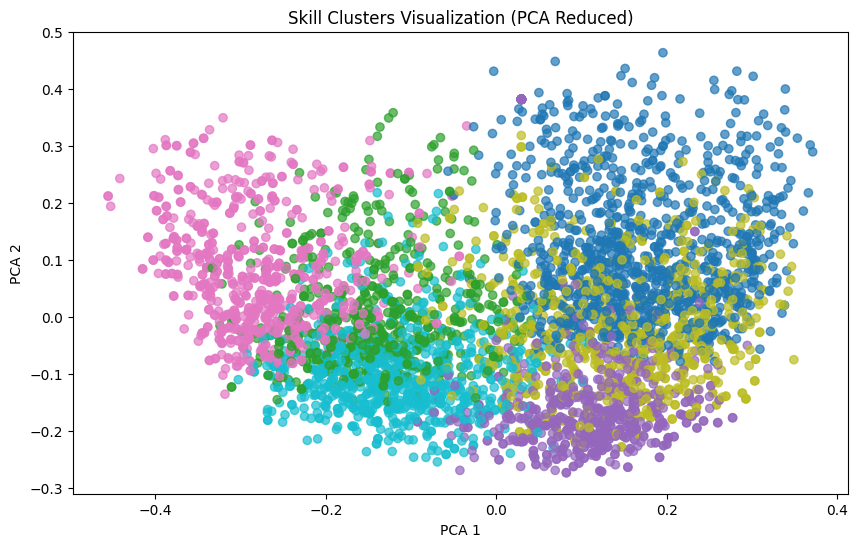

In [24]:
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(X)

plt.figure(figsize=(10,6))
plt.scatter(reduced[:,0], reduced[:,1], c=df["skill_cluster"], cmap='tab10', alpha=0.7)
plt.title("Skill Clusters Visualization (PCA Reduced)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

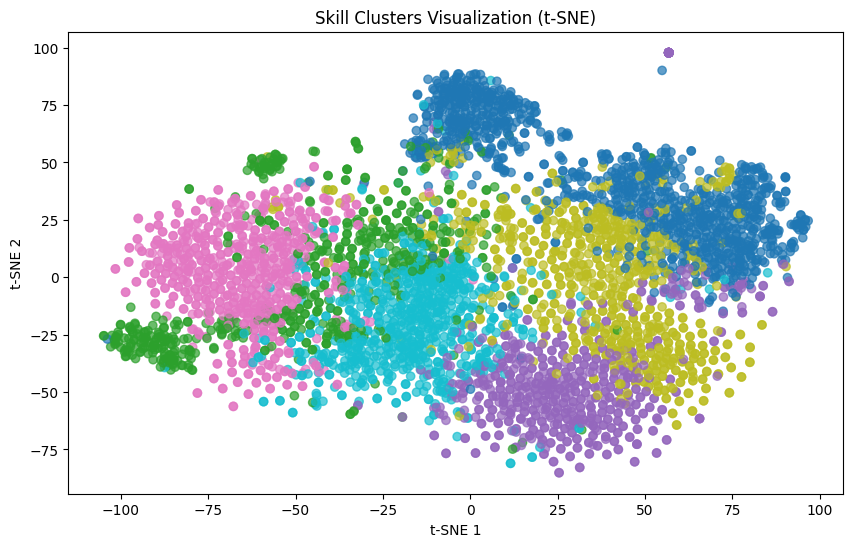

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42,
    init="pca"  
)

reduced = tsne.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(
    reduced[:, 0],
    reduced[:, 1],
    c=df["skill_cluster"],
    cmap="tab10",
    alpha=0.7
)
plt.title("Skill Clusters Visualization (t-SNE)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()


**SKILL RECOMMENDER (TF-IDF + COSINE SIMILARITY)**

In [27]:
# Fit TF-IDF on your skill column
tfidf = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf.fit_transform(df['total_skills'])

def recommend_skills(input_skills, top_n=10):
    """
    Recommend new skills by comparing input with similar profiles.
    Returns a clean list of top_n skill recommendations.
    """
    # Vectorize the input
    input_vec = tfidf.transform([input_skills])
    
    # Compute cosine similarity with all profiles
    sims = cosine_similarity(input_vec, X_tfidf).flatten()
    
    # Get top 5 similar profiles
    similar_profiles = df.iloc[sims.argsort()[-5:][::-1]]
    
    # Combine all skills from similar profiles
    all_related_skills = []
    for skills in similar_profiles['total_skills']:
        # Split on comma and strip extra spaces
        all_related_skills.extend([s.strip() for s in skills.split(",")])
    
    # Lowercase everything for comparison
    input_terms = set([s.strip().lower() for s in input_skills.split(",")])
    all_terms = set([s.lower() for s in all_related_skills])
    
    # Remove already known skills
    recommended = list(all_terms - input_terms)
    
    # Capitalize skill names nicely
    recommended = [s.title() for s in recommended]
    
    # Return top_n
    return recommended[:top_n]


In [43]:
recommender_bundle = {
    "tfidf": tfidf,
    "X_tfidf": X_tfidf,
    # "skills_series": df["total_skills"]
}

joblib.dump(recommender_bundle, "models/skill_recommender2.joblib")

['models/skill_recommender2.joblib']

In [36]:
print("KMeans centers dtype:", kmeans.cluster_centers_.dtype)
print("New embedding dtype:", np.array(new_emb).dtype)


KMeans centers dtype: float32
New embedding dtype: float64


**TEST WITH NEW PROFILE**

In [42]:
new_profile = {
    "total_skills": "Python, TensorFlow, Deep Learning, Machine Learning, NLP, Data Science"
}

# Embed new profile
new_emb = embed_texts([new_profile["total_skills"]])[0]
# cluster_id = kmeans.predict([new_emb])[0]
cluster_id = kmeans.predict(
    np.array([new_emb], dtype=np.float32)
)[0]

print(f"\n🧬 New profile belongs to cluster: {cluster_id}")

# Show similar profiles
print("\n🎯 Similar profiles in this cluster:")
print(df[df["skill_cluster"] == cluster_id][["current_position"]].head(5))

# Recommend new skills
print("\n💡 Recommended new skills:")
print(recommend_skills(new_profile["total_skills"]))



🧬 New profile belongs to cluster: 4

🎯 Similar profiles in this cluster:
            current_position
0                ML Engineer
1  Machine Learning Engineer
2  Python Software Developer
3  Machine Learning Engineer
4      Director - Applied AI

💡 Recommended new skills:
['Amazon Web Services (Aws)', 'Cloud Computing', 'Software Development', 'Mlops', 'Statistical Data Analysis', 'Analytical Skills', 'Devops', 'C#', 'Keras', 'Large Language Models (Llm)']


In [41]:
print(recommend_skills("Python, TensorFlow, Deep Learning, Machine Learning, NLP, Data Science"))


['Amazon Web Services (Aws)', 'Cloud Computing', 'Software Development', 'Mlops', 'Statistical Data Analysis', 'Analytical Skills', 'Devops', 'C#', 'Keras', 'Large Language Models (Llm)']
